## Global Emissions Analysis & Prediction ML

In [2]:
from google.colab import files
uploaded = files.upload()

Saving emissions.csv to emissions.csv


In [3]:
# ---------------------------
# Project Overview
# ---------------------------
# This project analyzes global CO2 emissions trends and predicts future emissions
# using a simple machine learning model (Linear Regression).

# ---------------------------
# Import Libraries
# ---------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


In [4]:

# ---------------------------
# Load Dataset
# ---------------------------
df = pd.read_csv("emissions.csv")
print("Dataset Preview:")
print(df.head())


Dataset Preview:
       country  year iso_code  population  gdp  cement_co2  \
0  Afghanistan  1750      AFG   2802560.0  NaN         0.0   
1  Afghanistan  1751      AFG         NaN  NaN         0.0   
2  Afghanistan  1752      AFG         NaN  NaN         0.0   
3  Afghanistan  1753      AFG         NaN  NaN         0.0   
4  Afghanistan  1754      AFG         NaN  NaN         0.0   

   cement_co2_per_capita  co2  co2_growth_abs  co2_growth_prct  ...  \
0                    0.0  NaN             NaN              NaN  ...   
1                    NaN  NaN             NaN              NaN  ...   
2                    NaN  NaN             NaN              NaN  ...   
3                    NaN  NaN             NaN              NaN  ...   
4                    NaN  NaN             NaN              NaN  ...   

   share_global_other_co2  share_of_temperature_change_from_ghg  \
0                     NaN                                   NaN   
1                     NaN                        

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# ---------------------------
# Data Preprocessing
# ---------------------------
df = df[["country", "year", "co2"]]
df = df.dropna()
df = df[df["year"] >= 2000]

print("\nCleaned Data:")
print(df.head())



Cleaned Data:
         country  year    co2
250  Afghanistan  2000  1.047
251  Afghanistan  2001  1.069
252  Afghanistan  2002  1.341
253  Afghanistan  2003  1.560
254  Afghanistan  2004  1.237


In [8]:

# ---------------------------
# Exploratory Data Analysis
# ---------------------------
yearly = df.groupby("year")["co2"].sum().reset_index()

print("\nYearly Aggregated Data:")
print(yearly.head())



Yearly Aggregated Data:
   year         co2
0  2000  168033.979
1  2001  169508.084
2  2002  172920.805
3  2003  181677.579
4  2004  187385.685


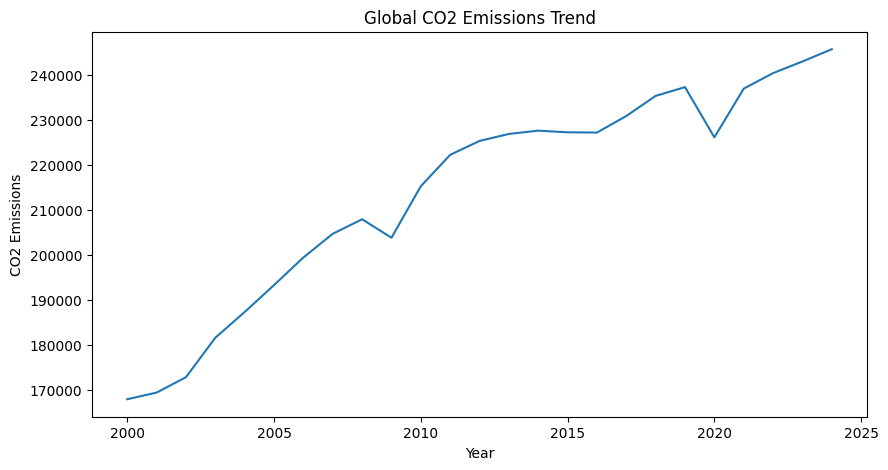

In [13]:
# ---------------------------
# Visualization: Emissions Trend
# ---------------------------
plt.figure(figsize=(10,5))
plt.plot(yearly["year"], yearly["co2"])
plt.title("Global CO2 Emissions Trend")
plt.xlabel("Year")
plt.ylabel("CO2 Emissions")
plt.savefig("trend_plot.png")
plt.show()


In [10]:

# ---------------------------
# Prepare Data for ML
# ---------------------------
X = yearly[["year"]]
y = yearly["co2"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------
# Build Model
# ---------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# ---------------------------
# Predictions
# ---------------------------
y_pred = model.predict(X_test)

# ---------------------------
# Model Evaluation
# ---------------------------
mse = mean_squared_error(y_test, y_pred)
print("\nMean Squared Error:", mse)


Mean Squared Error: 54430846.76369731


In [11]:
# ---------------------------
# Future Predictions
# ---------------------------
future_years = pd.DataFrame({"year": [2025, 2030, 2035]})
future_pred = model.predict(future_years)

print("\nFuture Predictions:")
for year, value in zip(future_years["year"], future_pred):
    print(f"{year}: {value}")



Future Predictions:
2025: 254452.10075124912
2030: 269980.26893002726
2035: 285508.4371088054


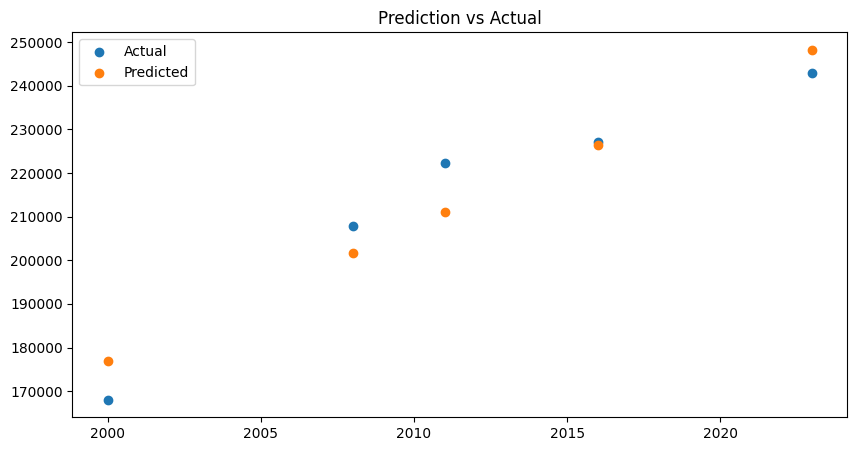

In [12]:

# ---------------------------
# Visualization: Predictions vs Actual
# ---------------------------
plt.figure(figsize=(10,5))
plt.scatter(X_test, y_test, label="Actual")
plt.scatter(X_test, y_pred, label="Predicted")
plt.legend()
plt.title("Prediction vs Actual")
plt.savefig("prediction_plot.png")
plt.show()